In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# device = torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 32

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [3]:

from diffSPH.dataLoader import *

folder = '/home/winchenbach/dev/datasets/testcase_II'

configuration = DataConfiguration(
    frameDistance=1,
    frameSpacing=1,
    maxRollout=1,
    historyLength=1,
    skipInitialFrames=0,
    cutoff=0
)

processed = processFolder(folder, configuration)

for file in processed:
    print(f'File: {file["fileName"]}, FrameCount: {len(file["frames"])}, Samples: {len(file["samples"])}, Style: {file["style"]}, Number of samples: {len(processed[0]["samples"])}, first sample: {processed[0]["samples"][0]}, last sample: {processed[0]["samples"][-1]}')


File: /home/winchenbach/dev/datasets/testcase_II/generative - 2023-03-22_14-22-55.hdf5, FrameCount: 3197, Samples: 3197, Style: testcase_II, Number of samples: 3197, first sample: 00001, last sample: 03197
File: /home/winchenbach/dev/datasets/testcase_II/generative - 2023-03-22_14-25-43.hdf5, FrameCount: 3197, Samples: 3197, Style: testcase_II, Number of samples: 3197, first sample: 00001, last sample: 03197


In [4]:
dataset, datasetLoader = getDataLoader(processed, 1, shuffle = True)
datasetIter = iter(datasetLoader)

nextData = next(datasetIter)
print(f'Next data: {nextData}')

# nextData = [0, 16, 64, 98]
# nextData = [9000]

Next data: [5828]


In [5]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

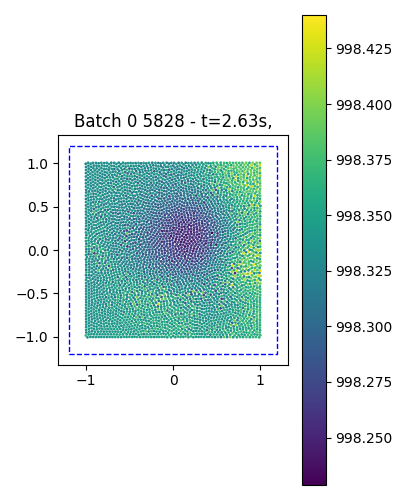

In [6]:
priorStates, currentState, trajectoryStates, domains, rotMats, configs, neighborhoods = loadAugmentedBatch(
    dataset, nextData, configuration, device = 'cuda', dtype = torch.float32,
    augmentAngle = False,
)

fig, axis = plt.subplots(1, len(nextData), figsize=(len(nextData) * 4, 5), squeeze = False)
# filteredNeighborhood = filterNeighborhoodByKind(currentStates[0], neighborhoods[0], 'noghost')

plots = []
axes = axis.flatten()
for b in range(len(domains)):
    plot = visualizeParticles(fig, axes[b],
                              particles = currentState,
                              domain = domains[b],
                              quantity = currentState.densities,
                              which = 'fluid',
                              mapping = 'L2',
                              cmap = 'viridis',
                              visualizeBoth=False,
                              kernel = kernelNameToKernel(configs[b]['kernel']),
                              plotDomain = True,
                              gridVisualization=False, markerSize=1,
                              batch = b, streamLines = False)
    axes[b].set_title(f'Batch {b} {nextData[b]} - t={currentState.time[b]:.2f}s,')
    plots.append(plot)

fig.tight_layout()

In [7]:
configs

[{'domain': {'dim': 2,
   'minExtent': tensor([-1.2000, -1.2000], device='cuda:0'),
   'maxExtent': tensor([1.2000, 1.2000], device='cuda:0'),
   'periodicity': tensor([False, False], device='cuda:0'),
   'periodic': False},
  'neighborhood': {'scheme': 'compact', 'verletScale': 1.4},
  'compute': {'device': 'cuda',
   'dtype': torch.float32,
   'precision': 'float32'},
  'kernel': {'name': 'Wendland2', 'targetNeighbors': 20},
  'boundary': {'active': True},
  'fluid': {'rho0': 1000, 'cs': 20},
  'particle': {'support': np.float32(0.07951923)},
  'shifting': {'CFL': 1.5}}]

In [8]:
currentState

WeaklyCompressibleSPHState(positions=tensor([[-1.0041, -0.9828],
        [-1.0003, -0.5707],
        [-0.9999, -0.6316],
        ...,
        [ 1.0317,  1.0952],
        [ 1.0635,  1.0952],
        [ 1.0952,  1.0952]], device='cuda:0'), supports=tensor([0.0795, 0.0795, 0.0795,  ..., 0.0795, 0.0795, 0.0795], device='cuda:0'), masses=tensor([0.9913, 0.9913, 0.9913,  ..., 0.9933, 0.9933, 0.9933], device='cuda:0'), densities=tensor([998.3698, 998.3344, 998.3356,  ..., 998.0000, 998.0000, 998.0000],
       device='cuda:0'), velocities=tensor([[ 0.0029,  0.0132],
        [ 0.0061, -0.0092],
        [ 0.0066, -0.0019],
        ...,
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000]], device='cuda:0'), kinds=tensor([0, 0, 0,  ..., 1, 1, 1], device='cuda:0'), materials=tensor([0, 0, 0,  ..., 0, 0, 0], device='cuda:0'), UIDs=tensor([   0,    1,    2,  ..., 4897, 4898, 4899], device='cuda:0'), numParticles=[4900], time=[np.float64(2.632999999999821)], dt=[np.float6

In [9]:
from diffSPH.dataLoaderUtils.resume import stateToState

state, particleSystem, config, domain, wrappedKernel, simulator, SimulationSystem, integrator, dt = stateToState(currentState, configs, domains, batch=0)
particles = particleSystem.systemState

In [10]:
from diffSPH.neighborhood import buildNeighborhood, computeNeighborhoodStates, filterNeighborhoodByKind, coo_to_csr
import numpy as np


mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]

neighborhood, sparseNeighborhood_ = buildNeighborhood(particles, particles, domain, verletScale = 1.4, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particles, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)



In [11]:
# particleState = wcstateToState(particles)
particleState = particleSystem.systemState
# neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)

# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

In [12]:
config['domain']

DomainDescription(min=tensor([-1.2000, -1.2000], device='cuda:0'), max=tensor([1.2000, 1.2000], device='cuda:0'), periodic=tensor([False, False], device='cuda:0'), dim=2)

In [13]:
traj = (trajectoryStates[0].positions - currentState.positions) / currentState.dt[0]
print('traj:', traj)
print(f'max: {traj.max()}, min: {traj.min()}, mean: {traj.mean()}, std: {traj.std()}')

traj: tensor([[ 0.0030,  0.0131],
        [ 0.0061, -0.0092],
        [ 0.0066, -0.0021],
        ...,
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000]], device='cuda:0')
max: 1.3402401208877563, min: -1.0831652879714966, mean: -0.0007367254584096372, std: 0.3900046646595001


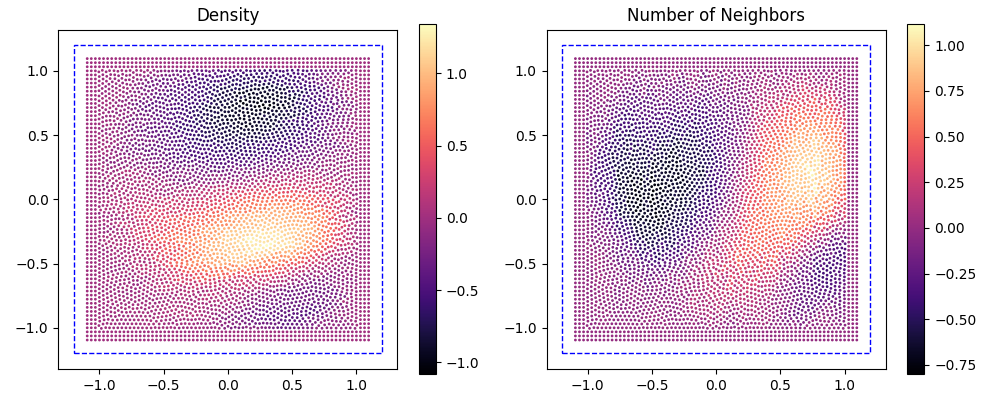

In [14]:
fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
markerSize = 1
visualizeParticles(fig, axis[0,0], particleState, config['domain'], traj, 
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', mapping = '.x',markerSize = markerSize, gridVisualization = False, title = 'Density')

visualizeParticles(fig, axis[0,1], particleState, config['domain'], traj, 
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', mapping = '.y',markerSize = markerSize, gridVisualization = False, title = 'Number of Neighbors')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [15]:
from ml import *
print(config)

{'targetNeighbors': 20, 'domain': DomainDescription(min=tensor([-1.2000, -1.2000], device='cuda:0'), max=tensor([1.2000, 1.2000], device='cuda:0'), periodic=tensor([False, False], device='cuda:0'), dim=2), 'kernel': None, 'correctiveOmega': True, 'neighborhood': {'scheme': 'compact', 'verletScale': 1.4}, 'support': {'iterations': 1, 'adaptiveHThreshold': 0.01, 'scheme': <AdaptiveSupportScheme.OwenScheme: 1>, 'targetNeighbors': 20, 'LUT': None}, 'fluid': {'rho0': 1000, 'cs': 20}, 'diffusion': {'alpha': 0.01}, 'diffusionSwitch': {'scheme': <ViscositySwitch.NoneSwitch: 6>, 'limitXi': False}, 'shifting': {'CFL': 1.5}, 'surfaceDetection': {'active': False}, 'pressure': {'term': 'Antuono'}, 'gravity': {'active': False}, 'regions': [], 'energyScheme': 'CRK', 'schemeName': 'CompSPH - NoneSwitch - Wendland2 - symplecticEuler', 'scheme': <SimulationScheme.DeltaSPH: 7>, 'integrationScheme': <IntegrationSchemeType.symplecticEuler: 13>, 'compute': {'device': 'cuda', 'dtype': torch.float32, 'precisi

In [16]:
inputFeatures = torch.cat([
    particleState.velocities,
    particleState.densities[:, None] / config['fluid']['rho0'],  # normalized density
    torch.ones_like(particleState.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

gt = traj.to(device)  # ground truth densities
gt = (particleState.densities[:, None] / config['fluid']['rho0'])[:, None].to(device)

gt = (trajectoryStates[0].velocities - currentState.velocities).to(device) / currentState.dt[0]

print(f'GT statistics: max: {gt.max()}, min: {gt.min()}, mean: {gt.mean()}, std: {gt.std()}')

GT statistics: max: 6.38854455947876, min: -6.880998134613037, mean: -0.06251494586467743, std: 1.0979459285736084


In [17]:
print(inputFeatures, gt)

tensor([[ 0.0029,  0.0132,  0.9984,  1.0000],
        [ 0.0061, -0.0092,  0.9983,  1.0000],
        [ 0.0066, -0.0019,  0.9983,  1.0000],
        ...,
        [ 0.0000,  0.0000,  0.9980,  1.0000],
        [ 0.0000,  0.0000,  0.9980,  1.0000],
        [ 0.0000,  0.0000,  0.9980,  1.0000]], device='cuda:0') tensor([[ 0.1307, -0.2466],
        [-0.2101, -0.0268],
        [-0.0989, -0.2397],
        ...,
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000]], device='cuda:0')


In [18]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

In [19]:
# inputEncoder = buildMLPwDict({
#  'inputFeatures': inputFeatures.shape[1],
#  'output' : 48,
#  'activation': 'celu',
#  'layout': [hiddenMLPSize] * inputEncoderLayers,
#  'norm': False,
#  'bias': False,
# }
# ).to(device)

# numberOfParameters = sum(p.numel() for p in inputEncoder.parameters())
# print(f'Number of parameters in input encoder: {numberOfParameters}')

# for i, layer in enumerate(inputEncoder):
#     print(f'Layer {i}: {layer}')

# encodedInput = inputEncoder(inputFeatures)
# encodedInputLR = inputEncoder(inputFeaturesLR)

In [20]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)


print(neighbors.neighbors.row.shape)
filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
# filteredNeighborhood = neighbors.neighbors

print(filteredNeighborhood.row.shape)


h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
sparse_edge_attr = xij_ / h_i[:,None]

print('Maximum distance: ', (rij / h_i).max().item())


# minD = domain.min
# maxD = domain.max
# periodicity = domain.periodic

# dense_xij = (particleState.positions[:,None] - particleState.positions)
# dense_mod_xij = torch.stack([dense_xij.reshape(nx**4, 2)[:,i] if not periodic_i else mod(dense_xij.reshape(nx**4, 2)[:,i], minD[i], maxD[i]) for i, periodic_i in enumerate(periodicity)], dim = -1).reshape(nx**2, nx**2, dim)

# print('dense_xij', dense_mod_xij.shape)
# print(dense_mod_xij.min())

torch.Size([93886])
torch.Size([93886])
Maximum distance:  0.999998152256012


In [21]:
torch.cuda.empty_cache()

In [22]:
from util import *
# adjacency = buildDenseNeighborhood(particleState, domain)
adjacency = buildSparseNeighborhood(filteredNeighborhood)

In [23]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [24]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency, normalize = False, mode = 'gather')

edge_attr = xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.row, adjacency.col])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

transformerFeatures = 11
multiHeads = 3
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = edge_attr.shape[-1]

node_attr = (inputFeatures.reshape(1, -1, inputFeatures.shape[-1]), inputFeatures.reshape(1, -1, inputFeatures.shape[-1]))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 1
node_attr_batched = (inputFeatures.repeat(bs, 1, 1), inputFeatures.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleState.positions.shape[0]
    cumCols += particleState.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

node_positions = (particleState.positions.reshape(1, -1, particleState.positions.shape[-1]).repeat(bs, 1, 1), particleState.positions.reshape(1, -1, particleState.positions.shape[-1]).repeat(bs, 1, 1 ))  # Reshape to [B, N, D] for batch processing

print('node_positions shape:', node_positions[0].shape, node_positions[1].shape)

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)


e_ij = torch.cat([edge_attr_batched, torch.linalg.norm(edge_attr_batched, dim=-1, keepdim=True),], dim=-1)
print(e_ij.shape)

spatial_features = edge_attr_batched
# rpb_features = basisEncoder(spatial_features).squeeze(0)

from layers.windows import getWindowFunction

windowValues = getWindowFunction('cubicSpline', norm = None)(torch.linalg.norm(edge_attr_batched, dim=-1))

edge_attr shape: torch.Size([93886, 2])
edge_index shape: torch.Size([2, 93886])
node_attr shape: torch.Size([1, 4900, 4]) torch.Size([1, 4900, 4])
Edge indices for batch 0: torch.Size([2, 93886])
node_positions shape: torch.Size([1, 4900, 2]) torch.Size([1, 4900, 2])
node_attr_batched shape: torch.Size([1, 4900, 4]) torch.Size([1, 4900, 4])
edge_attr_batched shape: torch.Size([93886, 2])
edge_indices_batched shape: torch.Size([2, 93886])
torch.Size([93886, 3])


In [25]:
from models.basicEncoder import BasicEncoder

# encoder = BasicEncoder(
#     input_dim = node_attr_batched[0].shape[-1],
#     output_dim = transformerFeatures * multiHeads,
#     hidden_layers = 2,
#     latent_dim = 32,
#     verbose = False,
# ).to(device)
# decoder = BasicEncoder(
#     input_dim = transformerFeatures * multiHeads,
#     output_dim = gt.shape[-1],
#     hidden_layers = 2,
#     latent_dim = 32,
#     verbose = False,
# ).to(device)

In [26]:
from models.common import CommonConfiguration
import copy


In [27]:
from models.basicTransformer import BasicTransformer
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel



In [62]:
class basicTest(nn.Module):
    def __init__(self, 
                 input_dim, output_dim,
                 transformer_features, multi_heads,
                 latent_dim, latent_layers,
                 encoderConfig, decoderConfig, transformerConfig, 
                 numTransformers, mode = 'transformer'):
        super(basicTest, self).__init__()
        self.inputEncoder = BasicEncoder(
            input_dim = input_dim,
            output_dim = transformer_features * multi_heads,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            verbose = False,
        )
        self.transformers = nn.ModuleList()
        for _ in range(numTransformers):
            if mode == 'transformer':
                transformer = BasicTransformer(
                    config = transformerConfig,
                    transformer_features = transformer_features,
                    attention_heads = multi_heads,

                    # attention_softmax = False,

                    verbose = False,
                )
            elif mode == 'cconv':
                transformer = CConvModel(
                    config=baseConfigNoEncoders,

                    verbose = False,
                )
            elif mode == 'gnn':
                transformer = GNNModel(
                    config = baseConfigNoEncoders,

                    use_edge_mlp=True,
                    use_edge_encoder = True,
                    inputEdgeEncoderTokenConfig = None,
                    verbose = False,
                )
            self.transformers.append(transformer)
        self.decoder = BasicEncoder(
            input_dim = transformer_features * multi_heads,
            output_dim = output_dim,
            hidden_layers = latent_layers,
            latent_dim = latent_dim,
            verbose = False,
        )

    def forward(self, node_attr, edge_attr, edge_index, node_positions):
        # print('Input node_attr shape:', node_attr.shape)
        x = self.inputEncoder(node_attr, inputPositions = node_positions)
        # print('Encoded input shape:', x.shape)
        for transformer in self.transformers:
            x = transformer(
                node_features = x,
                node_positions = node_positions[0],
                edge_indices = edge_index,
                edge_features = None,
                edge_spatial_features = edge_attr)
            # print('Transformed shape:', x.shape)
        out = self.decoder(x, inputPositions = node_positions)
        # print('Output shape:', out.shape)
        return out

multiHeads = 4
transformerFeatures = 11



baseConfigNoEncoders = CommonConfiguration(
    token_input_dim=transformerFeatures * multiHeads,
    token_output_dim=transformerFeatures * multiHeads,
    spatial_dim=dim,
    edge_feature_dim=0,

    latent_features=transformerFeatures * multiHeads,
    hidden_layers=4,

    use_encoder=False,
    inputEncoderTokenConfig = None,

    use_decoder=False,
    outputDecoderTokenConfig = None,

    basis_function = 'ffourier',
    basis_terms = 6,
    basis_mode = 'cat',
    basis_projection = 'cartesian',

    mlp_hidden_layers=2,
    mlp_latent_dim = 32,
    mlp_activation = 'silu',
)

baseConfig = copy.deepcopy(baseConfigNoEncoders)
baseConfig.use_encoder=True
baseConfig.use_decoder=True
baseConfig.token_input_dim=node_attr_batched[0].shape[-1]
baseConfig.token_output_dim=1
baseConfig.ffn_skip_last = True

basicModel = basicTest(
    input_dim = node_attr_batched[0].shape[-1],
    output_dim = gt.shape[-1],
    transformer_features = transformerFeatures,
    multi_heads = multiHeads,
    latent_dim = 32,
    latent_layers = 2,
    encoderConfig = None,
    decoderConfig = None,
    transformerConfig = baseConfigNoEncoders,
    numTransformers = 2,
    mode = 'transformer'
).to(device)

In [63]:
optimizer = torch.optim.Adam(basicModel.parameters(), lr=1e-2)
numberOfParameters = count_parameters(basicModel)
print(f'Number of parameters in the model: {numberOfParameters}')



basicPred = basicModel(node_attr_batched[0], edge_attr_batched, edge_indices_batched, node_positions[0]).squeeze(0)


print(basicPred)


Number of parameters in the model: 99904
tensor([[ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04],
        ...,
        [ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04],
        [ 1.2176e-05, -1.7462e-04]], device='cuda:0',
       grad_fn=<SqueezeBackward1>)


In [52]:
losses_transformer2 = []
for i in (tq := tqdm(range(2**14), desc='Training', unit='epoch')) :
    optimizer.zero_grad()
    basicPred = basicModel(node_attr_batched[0], edge_attr_batched, edge_indices_batched, node_positions[0]).squeeze(0)

    # print(basicPred.shape, gt.shape)
    # print(basicPred)
    fluidPred = basicPred[particleState.kinds == 0]
    fluidGT = gt[particleState.kinds == 0]

    fluidLoss = torch.nn.functional.mse_loss(fluidPred, fluidGT)
    # print('Fluid loss:', fluidLoss.item())

    # loss = torch.nn.functional.mse_loss(basicPred, gt)
    fluidLoss.backward()
    optimizer.step()
    tq.set_postfix({'loss': fluidLoss.item()})
    losses_transformer2.append(fluidLoss.item())

    # break

Training:   0%|          | 0/16384 [00:00<?, ?epoch/s]

In [64]:
fluidPred

tensor([[-0.0256, -0.3350],
        [-0.2464, -0.0208],
        [-0.2066, -0.1523],
        ...,
        [ 0.4167,  0.0299],
        [-0.1797,  0.3716],
        [-1.9295, -0.1846]], device='cuda:0', grad_fn=<IndexBackward0>)

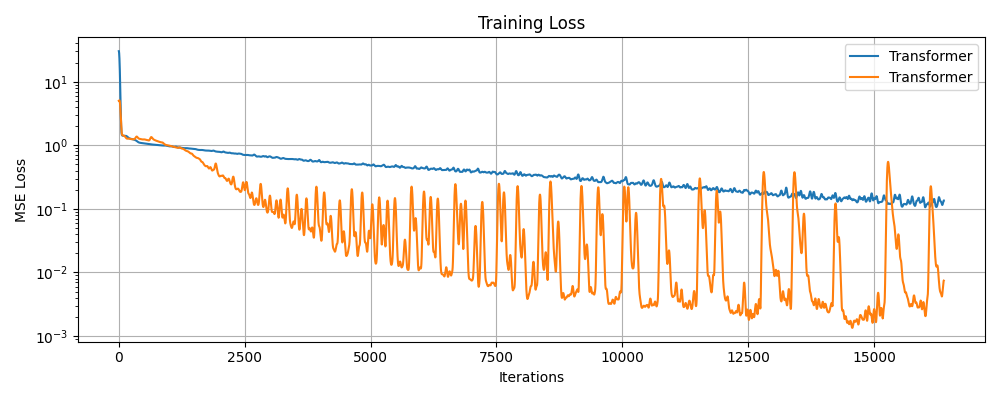

In [ ]:
fig, axis = plt.subplots(1,1 , figsize=(10,4), squeeze=False)

# axis[0,0].plot(gaussian_filter1d(losses, sigma=16), label = 'GNN')
axis[0,0].plot(gaussian_filter1d(losses_transformer, sigma=16), label = 'Transformer')
axis[0,0].plot(gaussian_filter1d(losses_transformer2, sigma=16), label = 'Transformer')
# axis[0,0].plot(gaussian_filter1d(losses_cconv, sigma=16), label = 'CConv')

axis[0,0].set_yscale('log')
axis[0,0].set_title('Training Loss')
axis[0,0].legend()

axis[0,0].grid(True)
axis[0,0].set_xlabel('Iterations')
axis[0,0].set_ylabel('MSE Loss')

fig.tight_layout()

In [ ]:

pred = basicPred.squeeze(0)

print('pred shape:', pred.shape, 'gt shape:', gt.shape)

loss = torch.nn.functional.mse_loss(pred, gt)
print('Loss:', loss.item())

pred shape: torch.Size([17196, 2]) gt shape: torch.Size([17196, 2])
Loss: 0.06757645308971405


In [ ]:
from models.ContinuousConvolution import CConvModel, BasicCConvLayer
from models.GNN import GNNModel


cconvModel = CConvModel(
    config=baseConfig,

    verbose = False,
).to(device)

cconvModelNoEncoders = CConvModel(
    config=baseConfigNoEncoders,

    verbose = False,
).to(device)


In [ ]:
outA = cconvModel(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(cconvModelNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))

In [ ]:
from models.GNN import GNNModel

gnn = GNNModel(
    config = baseConfig,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

gnnNoEncoders = GNNModel(
    config = baseConfigNoEncoders,

    use_edge_mlp=True,
    use_edge_encoder = True,
    inputEdgeEncoderTokenConfig = None,
    verbose = False,
).to(device)

In [ ]:
outA = gnn(
    node_features = node_attr_batched[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
)
outB = decoder(gnnNoEncoders(
    node_features = encodedNodes[0],
    node_positions = node_positions[0],
    edge_indices = edge_indices_batched,
    edge_features = None,
    edge_spatial_features = edge_attr_batched
))